## 1. Introduction

*Background information on PLAICraft (What it is, how it collects data, etc.) and then transition into the question*  
Source: https://plaicraft.ai/

Embodied artificial intelligence (AI) is AI that can think, act, and learn in real-world and digital in simulated environments. Such a program would be able to act like a real person in environments such as video games.

PLAICraft is a research data collection project that uses the video game "Minecraft" to work towards creating embodied AI. Using its own Minecraft server, they collect detailed information on how participants think and move while playing.

For the PLAICraft Minecraft server, the more hours the players play, the more data is collected.

Research data collection projects like PLAICraft need large amounts of data to be able to provide meaningful results, and therefore we need to be able to recruit participants that are likely to contribute a large amount of data.

Our question is based around the fact that we would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts.

Specifically, can the Age and experience of a player be used to predict the sum total of hours played across multiple sessions of PLAICraft?

Since the research team is looking for 'kinds' of players, we include Age as demographic information. We decided against including gender because the data is lacking in many observations for most genders, and so we don't have sufficient training data to use it as a predictor. experience is the one additional detail for 'type' of player, and we convert it from 5 discrete factors into a linear scale of 1-5 in the order Amateur, Beginner, Regular, Veteran, and Pro.

The researchers are asking to identify predictors for players who contribute a "large amount" of data which could be considered categorical, but we plan to treat it as a regression problem where we predict the numerical value of played_hours for a given type of player. This gives the researchers the ability to define their own cutoff for what minimum number of hours is considered 'large'.

In [1]:
library(tidyverse)
library(lubridate)
library(tidymodels)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [2]:
players <- read_csv("players.csv")
head(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


In [3]:
sessions <- read_csv("sessions.csv")
head(sessions)

Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


In [9]:
head(mutate(sessions, duration=dmy_hm(end_time)-dmy_hm(start_time), week_day = weekdays(dmy_hm(start_time))))

hashedEmail,start_time,end_time,original_start_time,original_end_time,duration,week_day
<chr>,<chr>,<chr>,<dbl>,<dbl>,<drtn>,<chr>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12,12 mins,Sunday
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12,13 mins,Monday
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12,23 mins,Thursday
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12,36 mins,Thursday
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12,11 mins,Saturday
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12,122 mins,Sunday


In [10]:
session_feature <- mutate(sessions,duration=dmy_hm(end_time)-dmy_hm(start_time),week_day=weekdays(dmy_hm(start_time))) |>
group_by(hashedEmail) |>
summarize(mean_time=mean(duration),ds_time=sd(duration),n=n())

head(session_feature)

hashedEmail,mean_time,ds_time,n
<chr>,<drtn>,<dbl>,<int>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,53.00000 mins,11.31371,2
060aca80f8cfbf1c91553a72f4d5ec8034764b05ab59fe8e1cf0eee9a7b67967,30.00000 mins,NA,1
0ce7bfa910d47fc91f21a7b3acd8f33bde6db57912ce0290fa0437ce0b97f387,11.00000 mins,NA,1
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,32.15385 mins,15.19784,13
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,35.00000 mins,16.97056,2
11006065e9412650e99eea4a4aaaf0399bc338006f85e80cc82d18b49f0e2aa4,10.00000 mins,NA,1


In [11]:
head(players)

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


The dataset includes two files, `players.csv` and `sessions.csv`.

`players.csv` includes information about each player, with 7 variables:

|Variable|Type|Description|
|-----------|-------|------------|
|experience|character|The player's experience level|
|subscribe|logical|If the player is subscribed to a game-related newsletter|
|hashedEmail|character|Unique hashed email of player|
|played_hours|double|Hours player has played|
|name|character|First name of player|
|gender|character|Gender of player|
|Age|double|Age of player (years)|

`sessions.csv` includes player activity, with 5 variables.

|Variable|Type|Description|
|-----------|-------|------------|
|hashedEmail|character|Unique hashed email of player|
|start_time|character|Date and time of when the session started|
|end_time|character|Date and time of when the session ended|
|original_start_time|double|Start time of the session in UNIX format (ms)|
|original_end_time|double|End time of the session in UNIX format (ms)|

The number of observations in each file:

In [12]:
obsPlayers <- summarize(players, count = n()) |> pull(count)
obsSessions <- summarize(sessions, count = n()) |> pull(count)
print(paste("Number of Observations in Players:", obsPlayers))
print(paste("Number of Observations in Sessions:", obsSessions))

[1] "Number of Observations in Players: 196"
[1] "Number of Observations in Sessions: 1535"


Some possible issues:

In [20]:
playersFilteredSeventeen <- filter(players, Age == 17)
playersFilteredTwentyOne <- filter(players, Age == 21)

obsplayersFilteredSeventeen <- summarize(playersFilteredSeventeen, count = n()) |> pull(count)
obsplayersFilteredTwentyOne <- summarize(playersFilteredTwentyOne, count = n()) |> pull(count)

total <- (obsplayersFilteredSeventeen) / obsPlayers * 100
print(paste("Percentage of players that are 17 years old:", total))

[1] "Percentage of players that are 17 years old: 37.2448979591837"


In [21]:
playersNoPlay <- filter(players, played_hours == 0)
playersLessPlay <- filter(players, played_hours <= 1)

obsPlayersNoPlay <- summarize(playersNoPlay, count = n()) |> pull(count)
obsPlayersLessPlay <- summarize(playersLessPlay, count = n()) |> pull(count)

print(paste("Number of players with zero hours played:", obsPlayersNoPlay))
print(paste("Number of players with zero to one hours played:", obsPlayersLessPlay))

[1] "Number of players with zero hours played: 85"
[1] "Number of players with zero to one hours played: 160"


In [15]:
summarizedPlayers <- summary(players)
summarizedPlayers

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

In [16]:
summarizedSessions <- summary(sessions)
summarizedSessions

 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

Mean for quantitative variables in `players.csv`:
|Variable|Mean|
|-------|-------|
|played_hours|5.85|
|Age|21.14|

Mean for quantitative variables in `sessions.csv`:
|Variable|Mean|
|-------|-------|
|original_start_time|1.72e+12|
|original_end_time|1.72e+12|

Warning message:
“tune samples were requested but there were 145 rows in the data. 140 will be used.”


[1] 5

[1] 24.05174

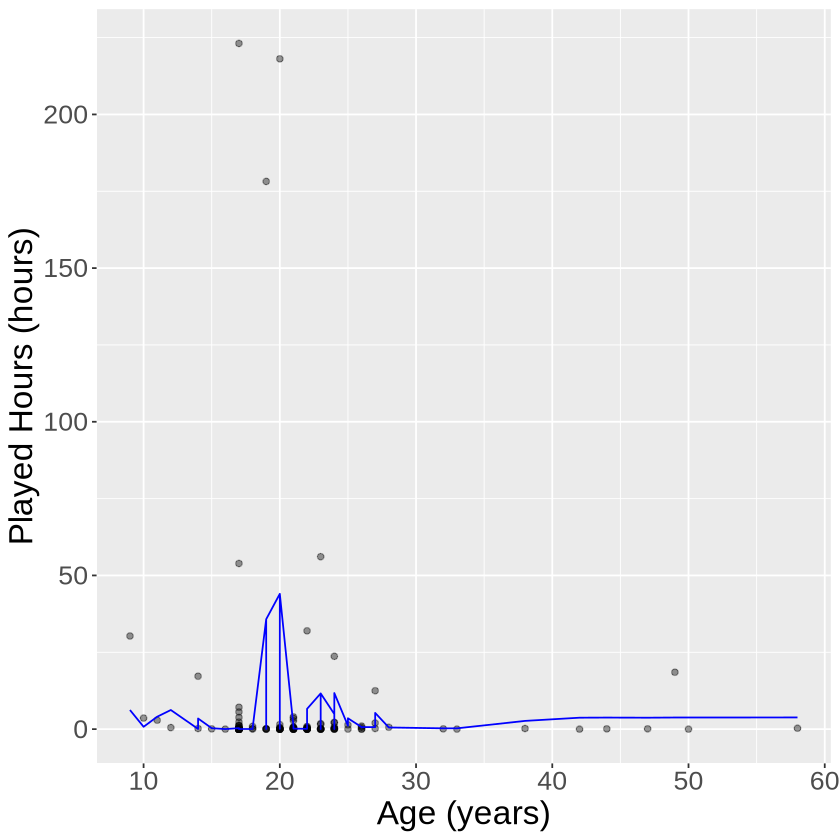

In [7]:
# Convert experience into a numeric scale, filter out NAs from Age
players_adjusted = players |>
    mutate(experience = case_when(experience == "Amateur" ~ 1,
                                experience == "Beginner" ~ 2,
                                experience == "Regular" ~ 3,
                                experience == "Veteran" ~ 4,
                                experience == "Pro" ~ 5)) |>
    select(Age, experience, played_hours) |>
    filter(!is.na(Age))

# Make our split of training/testing data
player_split = initial_split(players_adjusted, prop = 0.75, strata = played_hours)
player_training <- training(player_split)
player_testing <- testing(player_split)

# First tuning round of knn to find best count of neighbours
player_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = tune()) |>
            set_engine("kknn") |>
            set_mode("regression")

# scale necessary since Age is bigger range of numbers than experience
player_recipe <- recipe(played_hours ~ Age + experience, data = player_training) |>
    step_center(all_predictors()) |>
    step_scale(all_predictors())

players_vfold <- vfold_cv(player_training, v = 5, strata = played_hours)

player_fit <- workflow() |>
            add_recipe(player_recipe) |>
            add_model(player_spec) |>
            fit(data = player_training)

# test N from 1 to 50
gridvals <- tibble(neighbors = seq(from = 1, to = 50, by = 1))

player_results <- player_fit |>
  tune_grid(resamples = players_vfold, grid = gridvals) |>
  collect_metrics() |>
  filter(.metric == "rmse")

# print the N with the best rmse
k_min <- player_results |>
  filter(mean == min(mean)) |>
    pull(n)

k_min

# Now do it again but using that N we just figured out
minimized_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = k_min) |>
            set_engine("kknn") |>
            set_mode("regression")

player_workflow <- workflow() |>
            add_recipe(player_recipe) |>
            add_model(minimized_spec) |>
            fit(data = player_training)

# Do predictions on the training data
player_preds <- player_workflow |>
  predict(player_training) |>
  bind_cols(player_training)

# Visualize the prediction line on top of the actual data points
played_hour_predictions <- player_preds |>
    ggplot(aes(x = Age, y = played_hours)) +
        geom_point(alpha = 0.4) +
        geom_line(
            mapping = aes(x = Age, y = .pred), 
            color = "blue") +
        xlab("Age (years)") +
        ylab("Played Hours (hours)") +
        theme(text = element_text(size = 20))

played_hour_predictions

# Calculate the output the rmspe of the final model
test_results <- player_workflow |>
                    predict(player_testing) |>
                    bind_cols(player_testing) |>
                    metrics(truth = played_hours, estimate = .pred)                    

rmspe <- test_results |>
                filter(.metric == 'rmse') |>
                select(.estimate) |>
                pull()

rmspe